# nae example

The schema-free `>` DSL on a **real** OpenAI model, showcasing the seven shipped features.

**API key:** set `OPENAI_API_KEY` in your environment, or drop it in a `.env` at the repo
root (`OPENAI_API_KEY=sk-...`) — the setup cell calls `load_dotenv()`.

Each cell builds its own nodes, so you can run them in any order.

## 0. Setup

In [1]:
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

from nae import AgentNode, AgenticGraph, AgenticState, fanout
from nae.validation import GraphValidationError

load_dotenv()  # reads OPENAI_API_KEY from a .env at the repo root, if present

# One shared model — ChatOpenAI is stateless per call, so every node can reuse it.
llm = ChatOpenAI(model="gpt-5.4-nano")

print("ready — nae imported, llm =", llm.model_name)

ready — nae imported, llm = gpt-5.4-nano


## 1. Parallel fan-out + join  ·  token usage  ·  prompt caching

`start` fans out to two workers that run **concurrently**; `combine` is a deferred join that runs **once** after both. No `state=` → standard `AgenticState`; `message=` is the input shorthand; `prompt_cache=True` opts into OpenAI prompt caching; `out["token"]` reports per-model usage.

In [2]:
start = AgentNode(name="start", llm=llm,
                  node_prompt="Restate the user's request in one short line.")
worker_a = AgentNode(name="worker_a", llm=llm,
                     node_prompt="List two PROS of the topic in the conversation. Be brief.")
worker_b = AgentNode(name="worker_b", llm=llm,
                     node_prompt="List two CONS of the topic in the conversation. Be brief.")
combine = AgentNode(name="combine", llm=llm,
                    node_prompt="Weigh the pros and cons above into a one-sentence verdict.")

start > fanout(worker_a, worker_b) > combine
# equivalent: start > [worker_a, worker_b] > combine

graph = AgenticGraph(start_node=start, end_nodes={combine}, prompt_cache=True)
out = graph.invoke(message="Should a small team adopt a monorepo?")

print("final verdict:", out["messages"][-1].content)
print("\ntrace (both branches ran, join ran once):")
for line in out["log"]:
    print("  -", line)
print("\ntoken usage per model:")
for model, usage in out["token"].items():
    print(f"  {model}: {usage.get('total_tokens')} total")

final verdict: For a small team, a **monorepo is usually worth it only if you have real shared code and multiple related apps/services**, but it can be overkill if your projects are mostly independent and you don’t want added tooling and governance overhead.

trace (both branches ran, join ran once):
  - start:You’re asking whether a small development team should adopt a monorepo approach.
  - worker_a:- **Simplifies shared code and dependencies** across services/apps, reducing duplication.  
- **Centralizes tooling and CI/CD**, making consistent testing and releases easier across the repo.
  - worker_b:Two CONS of adopting a monorepo for a small team:
1) Increased tooling/setup complexity and higher maintenance overhead.  
2) Risk of slower development cycles or “big-repo sprawl” if not tightly governed.
  - combine:For a small team, a **monorepo is usually worth it only if you have real shared code and multiple related apps/services**, but it can be overkill if your projects are most

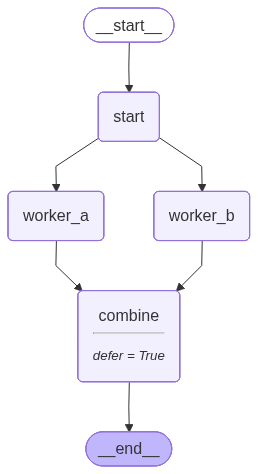

In [3]:
start > [worker_a, worker_b] > combine
AgenticGraph(start_node=start, end_nodes={combine}, prompt_cache=True)

## 2. Map-reduce  (with a list key so `reduce` gets clean input)

`summarize.map("docs")` fans the worker out via LangGraph `Send`, once per item of `state["docs"]`, all in parallel; `reduce` joins once after.

Key detail: each worker writes its summary into a **`summaries` list channel** (an append-reducer key), and `reduce` reads that *list* as input — not the shared `messages`. That matters because map outputs are `AIMessage`s; if `reduce` read them from `messages` it would see them as its own *assistant* turns and flounder (ask for more, or hallucinate). Reading a list key feeds them as plain input instead.

In [11]:
import operator
from typing import Annotated


# A list channel with an APPEND reducer: each parallel worker writes ONE summary
# into it (Send-safe), and `reduce` reads the whole list as input.
def append(a, b):
    return (a or []) + [b]


class MapState(AgenticState):
    docs: list
    summaries: Annotated[list, append]


dispatch = AgentNode(name="dispatch", llm=llm,
                     node_prompt="Reply with exactly: Summarizing.")
summarize = AgentNode(name="summarize", llm=llm,
                      node_prompt="Summarize the message in one short sentence.",
                      writes=["summaries"])              # each summary -> the list channel
reduce = AgentNode(name="reduce", llm=llm,
                   node_prompt=("Combine these document summaries into ONE digest. "
                                "Use only what is given:\n{summaries}"),
                   reads=["summaries"])                  # read the collected list, NOT messages

dispatch > summarize.map("docs") > reduce

graph = AgenticGraph(start_node=dispatch, end_nodes={reduce})
out = graph.invoke(
    message="summarize these",
    docs=[
        "LangGraph models agent workflows as a stateful graph of nodes and edges.",
        "Keras became the default high-level API for TensorFlow by winning on ergonomics.",
        "nae compiles a Pythonic '>' DSL down to a native LangGraph StateGraph.",
    ],
)
print("collected summaries:")
for s in out["summaries"]:
    print("  -", s)
print("\nfinal digest:", out["messages"][-1].content)
display(out["messages"][-1].content)

collected summaries:
  - LangGraph uses stateful graphs of nodes and edges to model agent workflows.
  - Keras became TensorFlow’s default high-level API due to its superior ergonomics.
  - nae compiles a Python-based “greater-than” DSL into a native LangGraph StateGraph.

final digest: - **LangGraph** uses **stateful graphs** of nodes and edges to model **agent workflows**.  
- **Keras** became **TensorFlow’s default high-level API** because it offers **superior ergonomics**.  
- **nae** compiles a **Python-based “greater-than” DSL** into a native **LangGraph `StateGraph`**.


'- **LangGraph** uses **stateful graphs** of nodes and edges to model **agent workflows**.  \n- **Keras** became **TensorFlow’s default high-level API** because it offers **superior ergonomics**.  \n- **nae** compiles a **Python-based “greater-than” DSL** into a native **LangGraph `StateGraph`**.'

In [14]:
from IPython.display import Markdown, display
display(Markdown(out["messages"][-1].content))

- **LangGraph** uses **stateful graphs** of nodes and edges to model **agent workflows**.  
- **Keras** became **TensorFlow’s default high-level API** because it offers **superior ergonomics**.  
- **nae** compiles a **Python-based “greater-than” DSL** into a native **LangGraph `StateGraph`**.

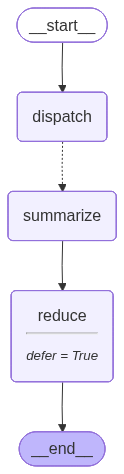

In [5]:
graph = AgenticGraph(state=MapState, start_node=dispatch, end_nodes={reduce})
graph

## 3. Schema-free typed multi-key IO

No custom `TypedDict`: `topic` (read, never written) auto-registers as an input; `sentiment`/`score` (written) auto-register too. `writes` as a `dict[str, type]` gives **typed** structured output, so `score` comes back a native `int`.

In [6]:
classify = AgentNode(
    name="classify",
    llm=llm,
    node_prompt="Rate the {topic} discussion. Return a sentiment and a 1-10 score.",
    reads=["messages", "topic"],
    writes={"sentiment": str, "score": int},
)

graph = AgenticGraph(start_node=classify, end_nodes={classify})   # no state=
out = graph.invoke(message="Honestly I loved it, fast and clean.", topic="product")
print(f"sentiment={out['sentiment']!r}  score={out['score']!r}  (score is a real {type(out['score']).__name__})")

sentiment='positive'  score=9  (score is a real int)


## 4. `graph.summary()` — the Keras-style table

node · type · reads · writes · available keys. (No model calls.)

In [7]:
s_start = AgentNode(name="start", llm=llm)
s_a = AgentNode(name="worker_a", llm=llm)
s_b = AgentNode(name="worker_b", llm=llm)
s_combine = AgentNode(name="combine", llm=llm)
s_start > fanout(s_a, s_b) > s_combine

g = AgenticGraph(start_node=s_start, end_nodes={s_combine})
g.summary()

AgenticGraph 'graph'   state=AgenticState
initial: decision, log, messages, token
------------------------------------------------------------------------
node      type       reads     writes        available                  
start     AgentNode  messages  log,messages  decision,log,messages,token
worker_a  AgentNode  messages  log,messages  decision,log,messages,token
combine   AgentNode  messages  log,messages  decision,log,messages,token
worker_b  AgentNode  messages  log,messages  decision,log,messages,token
------------------------------------------------------------------------
4 nodes · 0 errors · 0 warning(s)


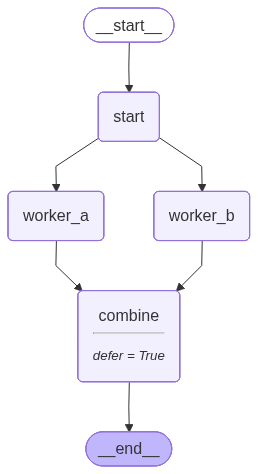

In [8]:
g

## 5. Build-time validation

Schema-free, but the guardrail still fires: `early` reads `summary`, which `late` writes **downstream** — read-before-write, caught at build on the default state. (No model calls.)

In [9]:
early = AgentNode(name="early", llm=llm, reads=["summary"])
late = AgentNode(name="late", llm=llm, output_field="summary")
early > late

try:
    AgenticGraph(start_node=early, end_nodes={late})   # no state=
    print("no error (unexpected)")
except GraphValidationError as e:
    print("caught GraphValidationError at build time:\n")
    print(e)

caught GraphValidationError at build time:

AgenticGraph 'graph': 1 error(s), 1 warning(s)
  [error] early: reads computed key 'summary' but no upstream node produces it before this node (produced by: ['late'], none of which are upstream); available keys here: ['decision', 'log', 'messages', 'token']
  [warning] early: declares scalar read 'summary' but node_prompt never interpolates {summary}; the value is fetched and silently ignored (dead read)
